In [1]:
import pandas as pd
import numpy as np
from scipy.interpolate import CubicSpline
import matplotlib.pyplot as plt

In [2]:
def OCV_curve():
    soc_points = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 
              55, 60, 65, 70, 75, 80, 85, 90, 95, 100]

    ocv_points = [3.00, 3.13, 3.40, 3.55, 3.62, 3.66, 3.68, 3.70, 
                  3.71, 3.72, 3.73, 3.74, 3.75, 3.77, 3.80, 3.84, 
                  3.90, 3.98, 4.06, 4.14, 4.20]
    
    cs = CubicSpline(soc_points, ocv_points)
    return cs
    

def get_SOC(SOC, I, C, t):
    return SOC - ((I * t) / C)

def get_voltage(SOC, I, R0, cs):
    return cs(SOC * 100).item() - I * R0


def execute(SOC, V):
    #setup
    #plot
    soc_true_hist = []
    soc_est_hist = []
    time_hist = []
    
    plt.ion()
    fig, ax = plt.subplots()
    line1, = ax.plot([], [], label="True SOC")
    line2, = ax.plot([], [], label="Estimated SOC")
    ax.legend()

    #values
    cs = OCV_curve()
    t = 0
    C = 820 * 3600 
    true_I = 0.8
    error_I = true_I * 0.02 #std
    R0 = 0.1
    P = np.array([[0.0001]])
    Q = np.array([[3]])
    R = np.array([[0.08]])
    
    while(SOC >= 0):
        #EKF preparation
        #current
        actual_I = true_I + np.random.normal(0, error_I)
        if (t == 0 ):
            true_SOC = SOC
        
        #SOC
        true_SOC = get_SOC(true_SOC, true_I, C, t) 

        #voltage
        measured_V = get_voltage(SOC, true_I, R0, cs)
        error_V = measured_V * 0.02 #std
        measured_V = measured_V + np.random.normal(0, error_V)

        #EKF equations
        #predict step
        A = np.array([[1]])
        new_SOC = get_SOC(SOC, actual_I, C, t)
        H = np.array([[cs(new_SOC, nu=1).item()]])
        pred_error = A @ P @ A.T + Q

        #measure step  
        #pred voltage
        pred_voltage = get_voltage(new_SOC, actual_I, R0, cs)

        #innovation
        y = measured_V - pred_voltage

        #kalman gain
        S = (H @ pred_error @ H.T + R)
        K = (pred_error @ H.T) @ (np.linalg.inv(S))

        #final SOC estimation + error estimation
        SOC = new_SOC + K * y
        P = (1 - K * H) * P
    
        time_hist.append(t)

        soc_true_hist.append(float(true_SOC))
        soc_est_hist.append(float(SOC))
    
        line1.set_data(time_hist, soc_true_hist)
        line2.set_data(time_hist, soc_est_hist)
    
        ax.relim()
        ax.autoscale_view()
    
        plt.draw()


        t = t + 0.5

    print("SIMULATION: SUCCESSFUL")
        
  

C:\Users\natha\AppData\Local\Temp\ipykernel_39408\4254670123.py:84: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  soc_est_hist.append(float(SOC))


SIMULATION: SUCCESSFUL


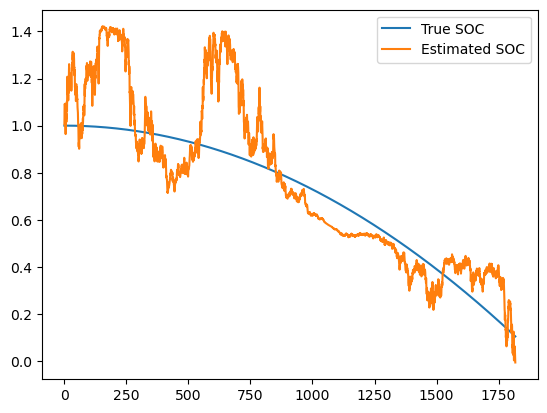

In [3]:
execute(1, 4.2)

In [ ]:
# generate smooth SOC values
x_smooth = np.linspace(0, 100, 500)
cs = OCV_curve()
# evaluate spline
y_smooth = cs(x_smooth)
soc_points = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 
              55, 60, 65, 70, 75, 80, 85, 90, 95, 100]

ocv_points = [3.00, 3.13, 3.40, 3.55, 3.62, 3.66, 3.68, 3.70, 
                  3.71, 3.72, 3.73, 3.74, 3.75, 3.77, 3.80, 3.84, 
                  3.90, 3.98, 4.06, 4.14, 4.20]
# plot
plt.plot(x_smooth, y_smooth, label="Spline")
plt.scatter(soc_points, ocv_points, color='red', label="Data points")

plt.xlabel("SOC (%)")
plt.ylabel("OCV (V)")
plt.legend()
plt.show()